# 06 · Metrics — how good is my model?

Every estimator in `dolcestat` — the GLMs and the k-NN models — returns a
**`PredictionAnalyzer`** from `predict()`. The analyzer holds the true and
predicted values and computes metrics on demand. This notebook is the home for
evaluation: what the metrics mean, how to read them, and *when they mislead*.

## Regression metrics

We fit a linear regression on apartment prices and ask its analyzer for the usual
suspects:

- **MSE / RMSE** — average squared error; RMSE is in the target's own units.
- **MAPE** — mean absolute error as a *percentage* of the true value.
- **R²** — fraction of variance explained (1 is perfect, 0 is a constant
  baseline).
- **Adjusted R²** — R² penalised for the number of features.

In [1]:
import numpy as np
import polars as pl

from dolcestat.preprocessing import DolceSet
from dolcestat.linear_models import LinearRegression, LogisticRegression

rng = np.random.default_rng(7)
n = 180
size = rng.uniform(45, 190, n)
rooms = rng.integers(1, 6, n).astype(float)
price = 3.0 * size + 25 * rooms + 60 + rng.normal(0, 18, n)   # strictly positive
df = pl.DataFrame({"size_m2": size, "rooms": rooms, "price_k": price})
reg_data = DolceSet()
reg_data.load_from_polars_dataframe(df, target_col="price_k")

report = LinearRegression().fit(reg_data).predict(reg_data)
print(f"RMSE        = {report.rmse():.2f} (thousand €)")
print(f"MAPE        = {report.mape():.2f}%")
print(f"R²          = {report.r2():.4f}")
print(f"Adjusted R² = {report.adjusted_r2():.4f}")

RMSE        = 16.93 (thousand €)
MAPE        = 2.95%
R²          = 0.9819
Adjusted R² = 0.9816


<Axes: xlabel='Residual', ylabel='Density'>

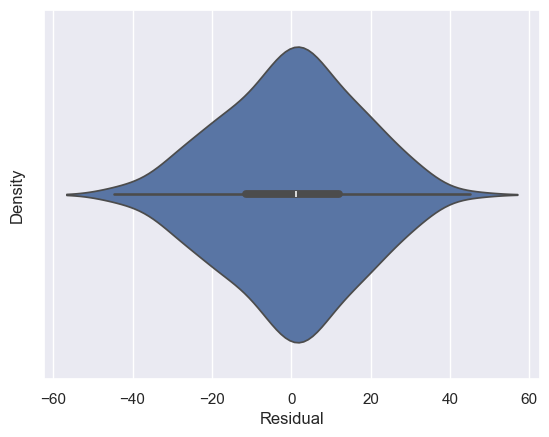

In [2]:
report.get_errors_violinplot("residuals")

### When regression metrics mislead

- **MAPE explodes near zero.** If the target can be close to (or cross) zero,
  percentage errors blow up — MAPE can read hundreds of percent on an otherwise
  excellent model. Prefer RMSE there, or `mape(metric="median")` to blunt
  outliers.
- **R² flatters wide-variance data.** A high R² only means you beat the mean
  baseline; on data with huge spread that's a low bar. Always read RMSE in the
  target's units alongside it.
- **Skewed / imbalanced targets.** With a long tail (a few very large values),
  squared-error metrics chase the outliers. Consider modelling `log(target)`,
  reporting the *median* absolute error, or weighting the tail explicitly.

## Classification metrics

For a classifier, the analyzer's `y_fit` holds class-1 probabilities. Most
metrics take a **threshold** that turns probabilities into predicted labels, and
derive their counts from the confusion matrix `(tp, tn, fp, fn)`.

In [3]:
c1 = rng.normal(0, 1, 300)
c2 = rng.normal(0, 1, 300)
prob = 1 / (1 + np.exp(-(1.5 * c1 - 2.0 * c2 + 0.4)))
labels = (rng.uniform(size=300) < prob).astype(int)
cdf = pl.DataFrame({"x1": c1, "x2": c2, "label": labels})
clf_data = DolceSet()
clf_data.load_from_polars_dataframe(cdf, target_col="label")

clf_report = LogisticRegression().fit(clf_data).predict(clf_data)

tp, tn, fp, fn = clf_report.confusion_matrix(threshold=0.5)
print(f"confusion (tp, tn, fp, fn) = {(tp, tn, fp, fn)}")
print(f"accuracy  = {clf_report.accuracy(0.5):.3f}")
print(f"precision = {clf_report.precision(0.5):.3f}")
print(f"recall    = {clf_report.recall(0.5):.3f}")
print(f"F1        = {clf_report.f1(0.5):.3f}")

confusion (tp, tn, fp, fn) = (133, 110, 32, 25)
accuracy  = 0.810
precision = 0.806
recall    = 0.842
F1        = 0.824


### Choosing the threshold: favouring precision or recall

The threshold is a dial, not a constant. Lower it and you predict "positive" more
readily — **recall rises and false negatives fall**, at the cost of more false
positives (lower precision). This is the knob to turn when one error type is
costlier than the other.

In [6]:
for t in (0.5, 0.3, 0.2):
    print(f"threshold {t}:  recall={clf_report.recall(t):.3f}  "
          f"precision={clf_report.precision(t):.3f}  "
          f"false-neg rate={clf_report.fn_rate(t):.3f}")

threshold 0.5:  recall=0.842  precision=0.806  false-neg rate=0.158
threshold 0.3:  recall=0.924  precision=0.692  false-neg rate=0.076
threshold 0.2:  recall=0.962  precision=0.650  false-neg rate=0.038


## Threshold-free metrics: ROC, AUC, BCE

Some metrics summarise the classifier across *all* thresholds at once:

- **ROC curve** — true-positive rate vs. false-positive rate as the threshold
  sweeps; **AUC** is the area under it (0.5 = coin flip, 1.0 = perfect).
- **BCE** — the log-loss the model was trained on; it reads the probabilities
  directly, rewarding calibrated confidence.

AUC = 0.872
BCE = 0.445


<Axes: >

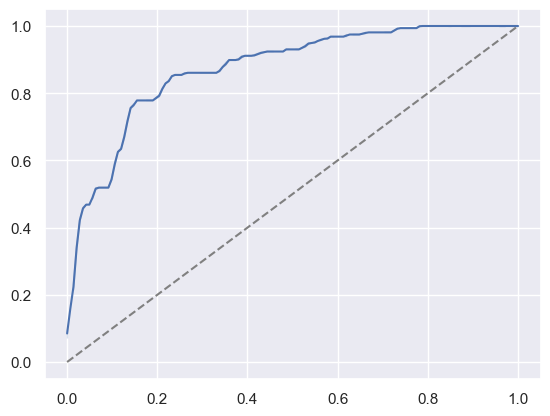

In [5]:
print(f"AUC = {clf_report.auc():.3f}")
print(f"BCE = {clf_report.bce():.3f}")
clf_report.roc_curve()

### When classification metrics mislead

- **Accuracy lies under class imbalance.** If 95% of examples are negative,
  predicting "always negative" scores 95% accuracy while catching *zero*
  positives. Prefer **precision/recall/F1** on the minority class, or **AUC**,
  and read the confusion matrix directly.
- **AUC can look great yet be useless** if you operate at a single threshold
  where the classifier is poorly calibrated — pair it with precision/recall at
  *your* threshold.
- **Imbalanced data.** Beyond the metrics above, consider resampling
  (over/under-sampling), class weights, or threshold tuning on a validation set
  rather than defaulting to 0.5.

The k-NN analyzers ([`05_knn`](05_knn.ipynb)) reuse this exact machinery:
`KNNRegressionAnalyzer` exposes the regression metrics and
`KNNClassificationAnalyzer` the classification ones (with neighbour weights /
class probabilities alongside).

## Recap — and the whole pipeline

You've now walked the full `dolcestat` loop: **preprocess → fit → evaluate**.
From here, mix and match — swap optimizers, try k-NN against a GLM, and read the
metrics that matter for *your* problem, minding the ways each one can mislead.